# I'm gonna run a test model here before diving deep into the ultimate model

## I. Introduction
This document only focus on a simple ML model using lightgbm to test the dataset.
I will note my progress making and trying simple model (only use libraries and modules) step-by-step.


## II, Tutorial
### Step 1: Import library.

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib
import matplotlib.pyplot as plt

### Step 2:Prepare the dataset

In [2]:
file_path = r'G:\url-analysis\src\data\malicious_phish_processed.csv'
whitelist_path = r'G:\url-analysis\src\data\domain.txt'
url_data = pd.read_csv(file_path, encoding_errors='ignore')
url_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 653490 entries, 0 to 653489
Data columns (total 66 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   url                               653490 non-null  str    
 1   type                              653490 non-null  str    
 2   url length                        653490 non-null  int64  
 3   number_of_part                    653490 non-null  int64  
 4   has_scheme                        653490 non-null  int64  
 5   has_netloc                        653490 non-null  int64  
 6   has_path                          653490 non-null  int64  
 7   has_params                        653490 non-null  int64  
 8   has_query                         653490 non-null  int64  
 9   has_fragment                      653490 non-null  int64  
 10  has_username                      653490 non-null  int64  
 11  has_password                      653490 non-null  int64  
 12 

### Step 3: split the dataset, X is the set of features used to test, y is the label

In [3]:
X = pd.DataFrame(url_data).drop(columns = ['url', 'type'])
print(X.head())

# y is the tag for supervised learning
y = url_data.type
print(y)

   url length  number_of_part  has_scheme  has_netloc  has_path  has_params  \
0          16               1           0           1         0           0   
1          35               2           0           1         1           0   
2          31               2           0           1         1           0   
3          88               4           1           1         1           0   
4         235               4           1           1         1           0   

   has_query  has_fragment  has_username  has_password  ...  download_param  \
0          0             0             0             0  ...               0   
1          0             0             0             0  ...               0   
2          0             0             0             0  ...               0   
3          1             0             0             0  ...               0   
4          1             0             0             0  ...               0   

   free_host  free_host_download  suspicious suffi

### Step 4: split X, y to X_train, X_test, y_train, y_test to train and test using LightGBM model

In [4]:
le = LabelEncoder()
encoded_y = le.fit_transform(y)
print(encoded_y)


X_train, X_test, y_train, y_test = train_test_split(X, encoded_y, test_size = 0.5, random_state = 32)
train_data = lgb.Dataset(X_train, label = y_train)
test_data = lgb.Dataset(X_test, label = y_test)

valid_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

params = {
    'objective' : 'multiclass',
    'num_class' : 4,
    'boosting_type' : 'gbdt',
    'learning_rate' : 0.05,
    'verbose' : 0
}

model_classification = lgb.LGBMClassifier(**params, valid_sets = [test_data, valid_data], num_boost_round = 2000 )
model_classification.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    eval_metric=['multi_logloss', 'auc_mu']
)

[3 0 0 ... 3 3 3]
[LightGBM] [Warning] object is set=, object= will be ignored. Current value: object=
[LightGBM] [Warning] at is set=, at= will be ignored. Current value: at=
[LightGBM] [Warning] Unknown parameter: 0x000002295968FB90>
[LightGBM] [Warning] Unknown parameter: valid_sets
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: at
[LightGBM] [Warning] Unknown parameter: 0x000002295AB369D0>,<lightgbm.basic.Dataset
[LightGBM] [Warning] num_iterations is set=2000, num_boost_round=2000 will be ignored. Current value: num_iterations=2000
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] object is set=, object= will be ignored. Current value: object=
[LightGBM] [Warning] at is set=, at= will be ignored. Current value: at=
[LightGBM] [Warning] Unknown parameter: valid_sets
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: at
[LightGBM] [Warning] Unknown parameter

,learning_rate,0.05
,objective,'multiclass'
,num_class,4
,verbose,0
,valid_sets,"[<lightgbm.bas...00229414B8850>, <lightgbm.bas...0022941534190>]"
,num_boost_round,2000
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,n_estimators,100
,subsample_for_bin,200000


In [5]:
y_pred = model_classification.predict_proba(X_test)
y_pred_classes = np.argmax(y_pred, axis = 1)


print("=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===")
accuracy = accuracy_score(y_test, y_pred_classes)
print(f"Độ chính xác (Accuracy): {accuracy:.4f}\n")

# In ra Classification Report chi tiết (Precision, Recall, F1-score)
# Sử dụng le.classes_ để map ngược lại tên chuỗi ban đầu (phishing, benign, malware, defacement)
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test,y_pred_classes, target_names=le.classes_))

# 3. Lưu mô hình (vì ở step 2 bạn đã import joblib)
model_filename = 'lgb_url_classifier.pkl'
joblib.dump(model_classification, model_filename)
print(f"Đã lưu mô hình thành công tại: {model_filename}")

[LightGBM] [Warning] object is set=, object= will be ignored. Current value: object=
[LightGBM] [Warning] at is set=, at= will be ignored. Current value: at=
[LightGBM] [Warning] Unknown parameter: valid_sets
[LightGBM] [Warning] Unknown parameter: object
[LightGBM] [Warning] Unknown parameter: at
[LightGBM] [Warning] Unknown parameter: 0x00000228C42DCD90>,<lightgbm.basic.Dataset
[LightGBM] [Warning] Unknown parameter: 0x0000022943179710>
=== KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH ===
Độ chính xác (Accuracy): 0.9747

Báo cáo phân loại chi tiết:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99    214018
  defacement       0.98      1.00      0.99     48437
     malware       0.99      0.95      0.97     16154
    phishing       0.94      0.89      0.91     48136

    accuracy                           0.97    326745
   macro avg       0.97      0.96      0.96    326745
weighted avg       0.97      0.97      0.97    326745

Đã lưu mô hình thành công tạ

### Step 5: Check the importance of feature

['url', 'type', 'url length', 'number_of_part', 'has_scheme', 'has_netloc', 'has_path', 'has_params', 'has_query', 'has_fragment', 'has_username', 'has_password', 'has_port', 'has_subdomain', 'has_domain', 'has_suffix', 'netloc_length', 'path_length', 'query_length', 'fragment_length', 'subdomain_length', 'domain_length', 'url_entropy', 'netloc_entropy', 'path_entropy', 'query_entropy', 'subdomain_entropy', 'domain_entropy', 'number_of_subdomain', 'hyphen_in_subdomain', 'hyphen_in_domain', 'unicode', 'punycode', 'at_sign_in_netloc', 'slash_in_path', 'dot_in_path', 'strange_in_query', 'equal_in_query', 'ampersand_in_query', 'normalized_levenshtein_domain', 'normalized_levenshtein_subdomain', 'random_domain_check', 'random_subdomain_check', 'number_ratio_domain', 'number_ratio_subdomain', 'repeated_domain_check', 'repeated_path_check', 'repeated_url_check', 'longest_repeated_chain', 'ip_domain', 'suspicious_key_domain', 'suspicious_key_subdomain', 'suspicious_key_path', 'suspicious_key_q

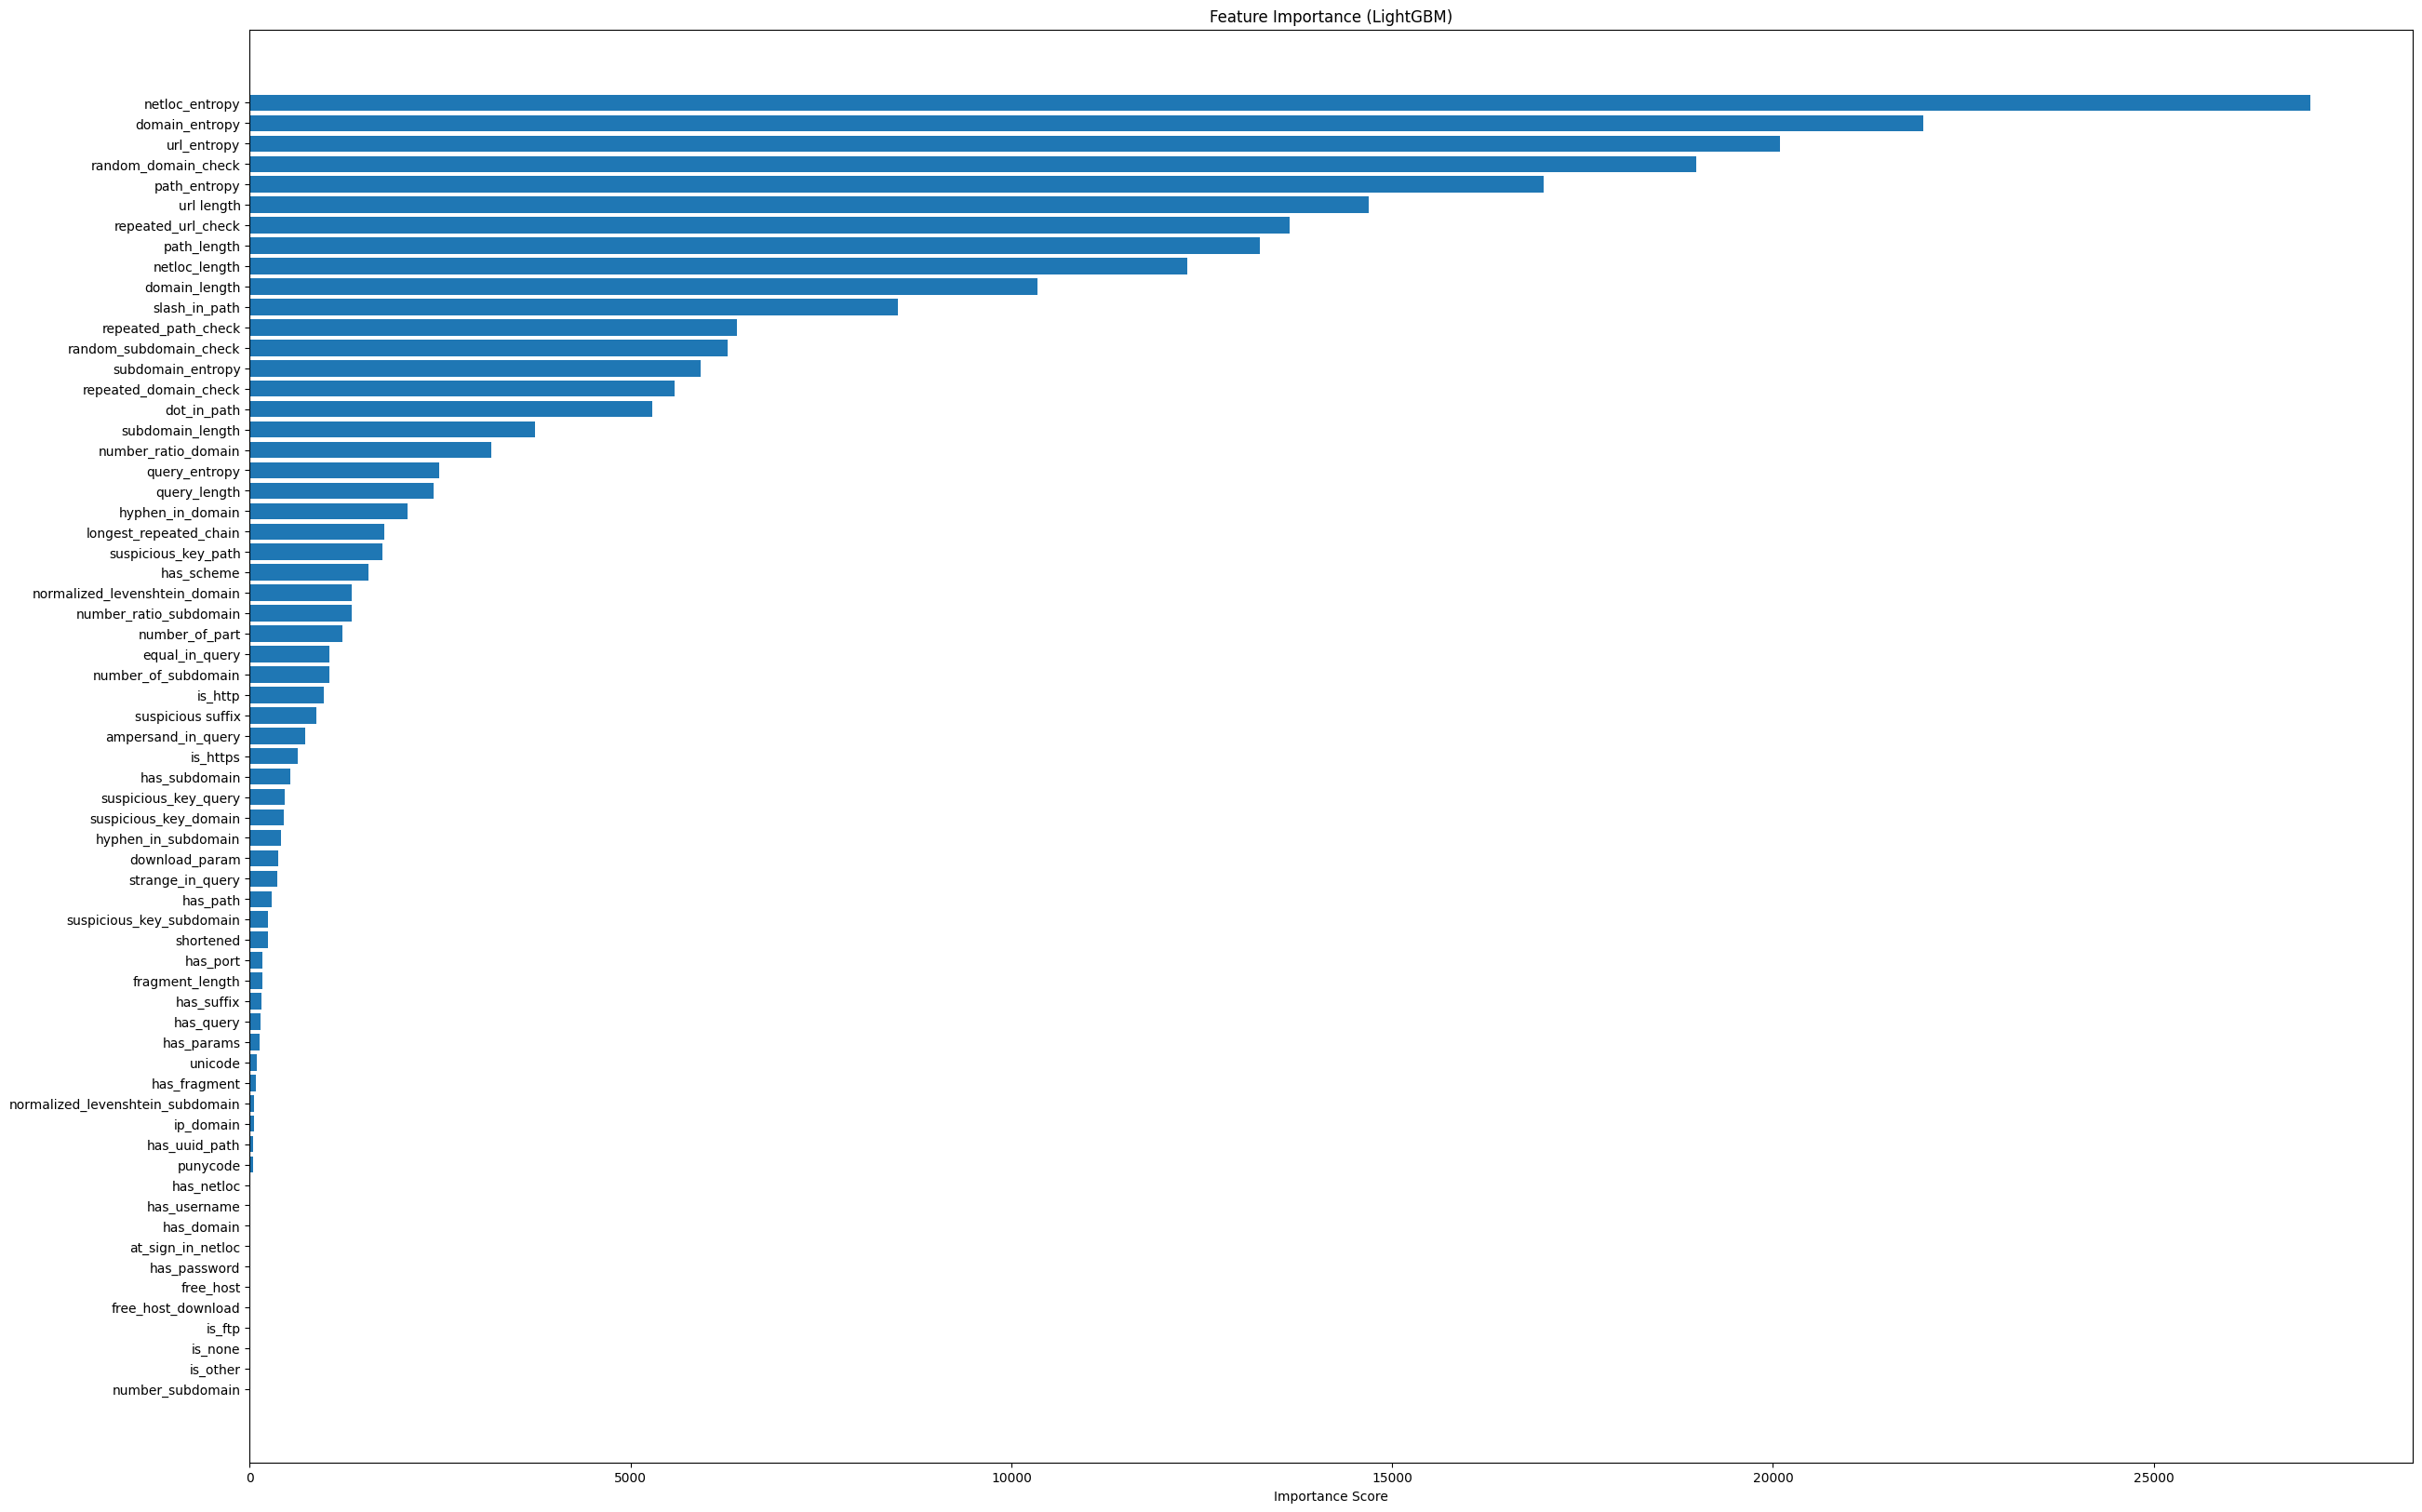

In [6]:
col_list = url_data.columns.tolist()
print(col_list)

importances = model_classification.feature_importances_
importance_df = pd.DataFrame(
    {
        "feature" : X.columns,
        "importance" : importances
    }
).sort_values(by="importance", ascending = False)
print(importance_df)

plt.figure(figsize=(30,20))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance (LightGBM)")
plt.xlabel("Importance Score")
plt.show()